## The purpose of this experiment to answer these questions
- Can i predict the mask from any new H pose camera?
- The prediction will be better?
- Can i reveal the iddent state sigms?
- Can i reveal the depth map?

## Part 5 Train (neglict ci)

## import libraries

In [1]:

from __future__ import annotations
from pathlib import Path
from typing import List
import platform
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt

# nerflab imports (make sure your env has nerflab on PYTHONPATH)
from nerflab import Intrinsics, Camera, CFG, load_world, plot_world
from nerflab.io import load_batch_simple, discover_cfg_hash, get_frame_ids_for_case
from nerflab.viz.render import Renderer, BinaryRenderCfg
from nerflab.viz.plot_nonzero_sigma import plot_nonzero_sigma_row
from nerflab.viz.viz_sigma import viz_sigma_heatmap, viz_sigma_scatter  # adjust import if needed



In [2]:
# gpu_check.py

print(f"PyTorch           : {torch.__version__}")
print(f"Python            : {platform.python_version()} ({sys.executable})")
print(f"CUDA available    : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA toolkit ver. : {torch.version.cuda}")
    print(f"CuDNN ver.        : {torch.backends.cudnn.version()}")
    print(f"GPU count         : {torch.cuda.device_count()}")
    for idx in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(idx)
        print(f"  · Device {idx}: {props.name} "
              f"({props.total_memory/1024**3:.1f} GB, "
              f"Compute {props.major}.{props.minor})")
else:
    print("→  No CUDA GPU detected by PyTorch.")


PyTorch           : 2.7.1+cu128
Python            : 3.10.12 (/home/elyamani/Main/programming/nerf-lab/.venv/bin/python)
CUDA available    : True
CUDA toolkit ver. : 12.8
CuDNN ver.        : 90701
GPU count         : 1
  · Device 0: NVIDIA GeForce RTX 4050 Laptop GPU (5.6 GB, Compute 8.9)


In [3]:

# ---- Parameters (edit these) ----
scene_dir = Path("../data/data_experiment1")  # root scene directory
split = "train"                   # one of: "train", "val", "test"
seed = 7
cfg_hash = None                  # if None, auto-discover from cache folder
num_frames = 100
frame_offset = 0
device = "cpu"                   # set "cuda" if available
show_world = True               # set True to plot the world and selected camera
world_json_path = "../data/world.json"  # update if your world.json lives elsewhere


In [4]:
# ---- Discover cfg_hash and list NPZ frames ----
_cfg = cfg_hash or discover_cfg_hash(scene_dir, split)


In [5]:
frame_ids, cfg_used = get_frame_ids_for_case(
    scene_dir, split,
    seed=seed,
    cfg_hash=cfg_hash,
    num_frames=num_frames,
    frame_offset=frame_offset,
)
print(f"Total data frames: {len(frame_ids)}")


Total data frames: 100


In [6]:
batch = load_batch_simple(scene_dir, frame_ids)

In [7]:
print("=== Batch Summary ===")
print(f" Width         : {batch['width']}")
print(f" Height        : {batch['height']}")
print(f" #Frame IDs    : {len(batch['frame_ids'])}")
print(f" #Image paths  : {len(batch['image_paths'])}")
print(f" Images shape  : {batch['images'].shape}")
print(f" H_wc shape    : {batch['H_wc'].shape}")
print("======================")


=== Batch Summary ===
 Width         : 640
 Height        : 480
 #Frame IDs    : 100
 #Image paths  : 100
 Images shape  : torch.Size([100, 480, 640])
 H_wc shape    : torch.Size([100, 4, 4])


In [8]:
images = batch['images']
H_wc = batch['H_wc']
cam = Camera(H_wc)
K = CFG.rays.R
# 5.3 RNG for reproducible pixel sampling
rng = torch.Generator(device=device)
rng.manual_seed(7)
    


In [ ]:
# RANDOM samples for training
    
Osub, Dsub, idx_lin, uv_int = cam.get_rays_sampled(rays_per_pose=K, rng=rng, return_indices=True )
print("subset shapes:", Osub.shape, Dsub.shape)  # (K,3)

t, delta, pts = cam.sample_along_rays(Osub, Dsub, rng=rng)
print("sample shapes:", t.shape, delta.shape, pts.shape)
print(idx_lin)
print(uv_int)

subset shapes: torch.Size([100, 4096, 3]) torch.Size([100, 4096, 3])
sample shapes: torch.Size([100, 4096, 40]) torch.Size([100, 4096, 40]) torch.Size([100, 4096, 40, 3])
tensor([[216903, 281415, 207820,  ..., 293533,  96019, 222035],
        [153461, 208977, 288892,  ...,  56355,  77615, 169506],
        [185998, 252575,  57048,  ...,  73757, 283360, 116888],
        ...,
        [112641,  85029,  76210,  ..., 215944, 124102, 109416],
        [138335,  73861,  52371,  ..., 291412, 124807,  42767],
        [ 45384, 196754,  14600,  ..., 239288, 151979, 131159]])
tensor([[[583, 338],
         [455, 439],
         [460, 324],
         ...,
         [413, 458],
         [ 19, 150],
         [595, 346]],

        [[501, 239],
         [337, 326],
         [252, 451],
         ...,
         [ 35,  88],
         [175, 121],
         [546, 264]],

        [[398, 290],
         [415, 394],
         [ 88,  89],
         ...,
         [157, 115],
         [480, 442],
         [408, 182]],

     

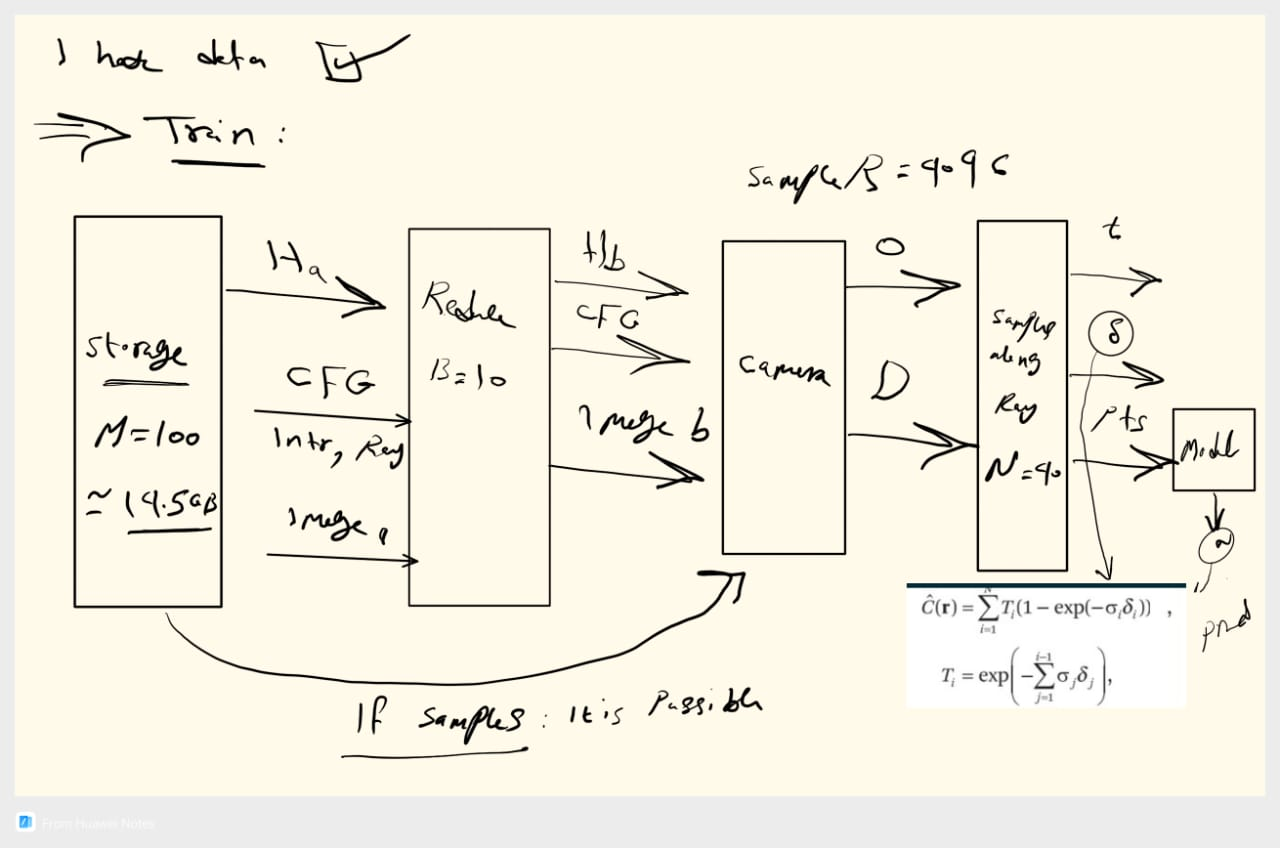

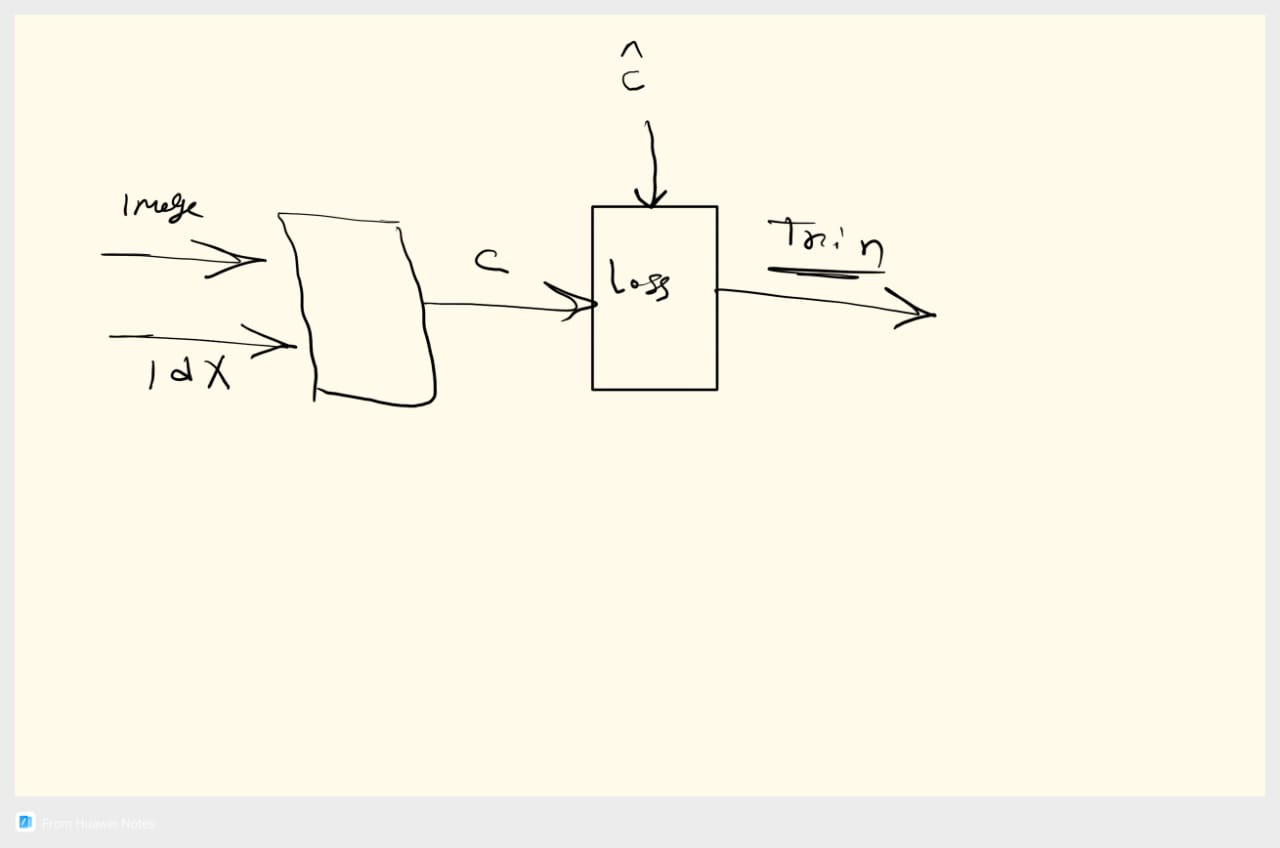

In [ ]:
idx_render = 2

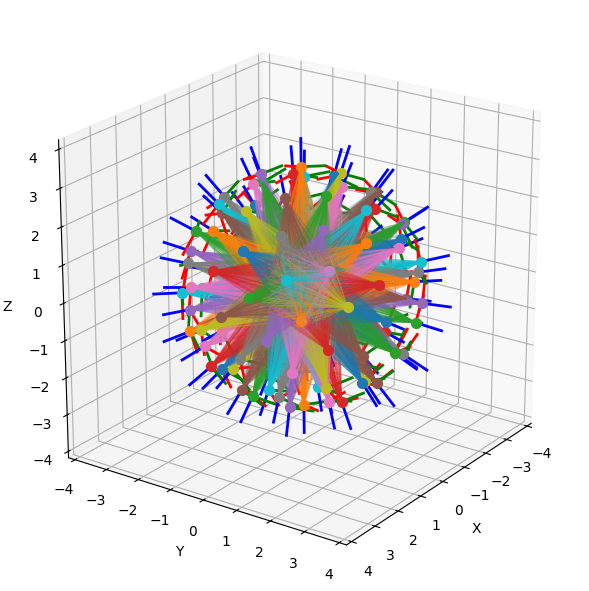

In [ ]:

# ---- Optional: plot the world and selected camera ----
if show_world:
    try:
        world = load_world(world_json_path)
        cam = cam
        idx = max(0, min(idx_render, cam.B - 1))
        plot_world(
            world,
            cameras=cam,
            # cam_indices=[idx],
            cam_indices='all',
            draw_rays=True,
            ray_mode="lines",
            rays_per_pose=100,
            samples_deterministic=False,
            ray_alpha=0.25,
            samples_alpha=0.1,
            shape_edge_alpha=1.0,
            shape_face_alpha=0.6,
            set_labels=False,
        )
        plt.show()
    except Exception as e:
        print("World plot skipped due to error:", e)


In [ ]:

# ---- Visualize sigma & opacity for a chosen frame ----
idx = idx_render
H, W = int(batch["height"]), int(batch["width"])


C = batch["images"][idx]          # (R,)


# Downsample for scatter to keep it light
R = H * W
N = t_np.shape[-1]
stride_r = max(1, R // 5000)   # adjust if you want fewer/more points
stride_n = max(1, N // 16)


# Opacity mask render
rnd = Renderer(BinaryRenderCfg(threshold=0.5))
fig, ax, _ = rnd.binary(
    C.reshape(H, W).detach().cpu().numpy(),
    intr=Intrinsics(**CFG.intrinsics.__dict__),
    title=f"Opacity frame {frame_ids[idx]}",
    save_path=str(scene_dir / f"opacity_{frame_ids[idx]}.png"),
)
plt.show()



NameError: name 't_np' is not defined